In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary': '#1D9E75', 'secondary': '#534AB7', 'accent': '#D85A30', 'neutral': '#888780'}

# Cargar dataset
df = pd.read_csv('ai4i2020.csv')

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFailure rate: {df['Machine failure'].mean()*100:.1f}%")
print()
print(df.head())

Records: 10,000
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Failure rate: 3.4%

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3  

4% failure rate — a very unbalanced dataset, just like the dropout rate. `class_weight='balanced'`.
5 failure types: TWF (tool wear), HDF (heat dissipation), PWF (power failure), OSF (overload), RNF (random failure).
Sensor variables — temperature, speed, torque, wear 

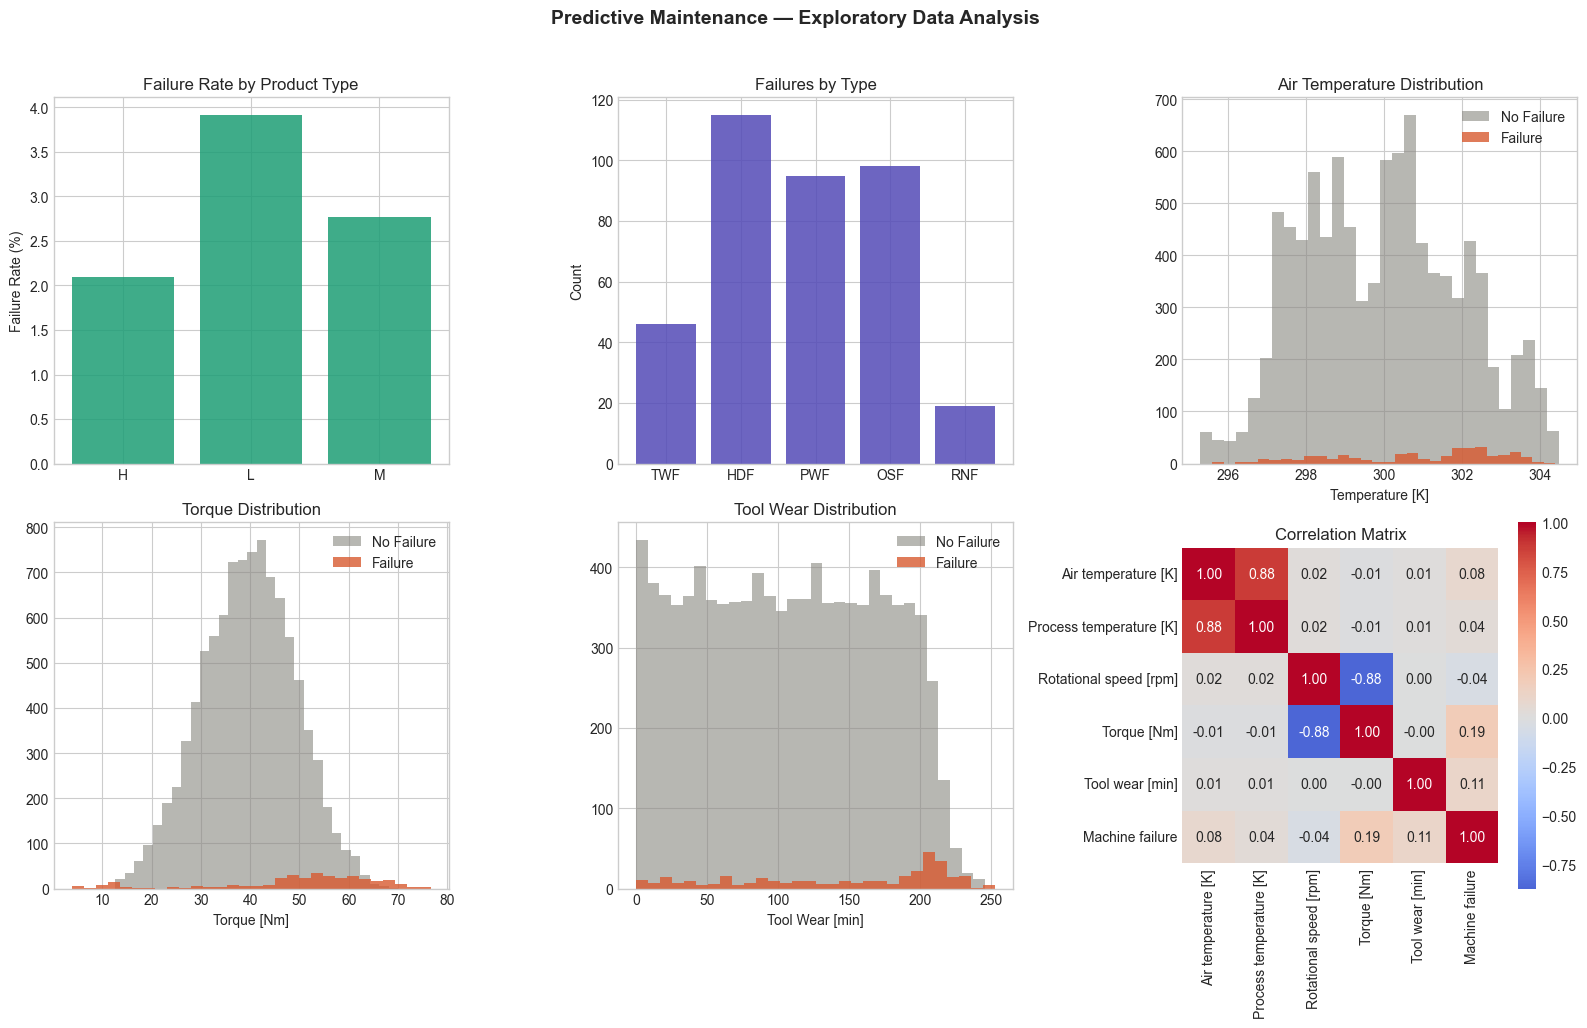

In [ ]:
# ── EDA Completo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribución de fallas por tipo de producto
failure_by_type = df.groupby('Type')['Machine failure'].agg(['sum','count','mean'])
failure_by_type.columns = ['Failures', 'Total', 'Rate'] # Tasa de falla
axes[0,0].bar(failure_by_type.index, failure_by_type['Rate']*100, color=COLORS['primary'], alpha=0.85) 
axes[0,0].set_title('Failure Rate by Product Type')
axes[0,0].set_ylabel('Failure Rate (%)')

# 2. Tipos de falla
failure_types = df[['TWF','HDF','PWF','OSF','RNF']].sum()
axes[0,1].bar(failure_types.index, failure_types.values, color=COLORS['secondary'], alpha=0.85)
axes[0,1].set_title('Failures by Type')
axes[0,1].set_ylabel('Count')

# 3. Temperatura vs Falla
axes[0,2].hist(df[df['Machine failure']==0]['Air temperature [K]'], #aquí separamos por falla o no falla y tomo temperatura del aire oardenada y frecuencia en el eje x
               bins=30, alpha=0.6, color=COLORS['neutral'], label='No Failure')
axes[0,2].hist(df[df['Machine failure']==1]['Air temperature [K]'], 
               bins=30, alpha=0.8, color=COLORS['accent'], label='Failure')
axes[0,2].set_title('Air Temperature Distribution')
axes[0,2].set_xlabel('Temperature [K]')
axes[0,2].legend()

# 4. Torque vs Falla
axes[1,0].hist(df[df['Machine failure']==0]['Torque [Nm]'], 
               bins=30, alpha=0.6, color=COLORS['neutral'], label='No Failure')
axes[1,0].hist(df[df['Machine failure']==1]['Torque [Nm]'], 
               bins=30, alpha=0.8, color=COLORS['accent'], label='Failure')
axes[1,0].set_title('Torque Distribution')
axes[1,0].set_xlabel('Torque [Nm]')
axes[1,0].legend()

# 5. Tool Wear vs Falla
axes[1,1].hist(df[df['Machine failure']==0]['Tool wear [min]'], 
               bins=30, alpha=0.6, color=COLORS['neutral'], label='No Failure')
axes[1,1].hist(df[df['Machine failure']==1]['Tool wear [min]'], 
               bins=30, alpha=0.8, color=COLORS['accent'], label='Failure')
axes[1,1].set_title('Tool Wear Distribution')
axes[1,1].set_xlabel('Tool Wear [min]')
axes[1,1].legend()

# 6. Correlación
corr_cols = ['Air temperature [K]', 'Process temperature [K]', 
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1,2], center=0, square=True)
axes[1,2].set_title('Correlation Matrix')

plt.suptitle('Predictive Maintenance — Exploratory Data Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_maintenance.png', dpi=150, bbox_inches='tight')
plt.show()